# Project #3 Task 4: ANN Modelling and Model Performance Evaluation

**Sivert Tilset (273412) and Robel Weldemichael(267200) and Mohammed Jama()**

Date: **10.11.2024**
       

**Abstact.**
This study investigates the prediction of P-wave velocity (Vp) using multiple machine learning techniques and literature-based models, focusing on optimizing the prediction accuracy through feature selection, model configurations, and comparative analysis. The primary input features—density (DEN), neutron porosity (NEU), and shear wave velocity (Vs)—were tested individually and in combinations to identify the optimal predictors for Vp.

A systematic evaluation of Artificial Neural Network (ANN) architectures was conducted, experimenting with combinations of optimizers (Adam, RMSprop) and activation functions (ReLU, LeakyReLU, Swish). The performance was measured using R², MSE, and RMSE metrics. Results indicated that the combination of all three features (DEN, NEU, Vs) with the RMSprop optimizer and Swish activation function yielded the best ANN model with an R² of 0.9594, an MSE of 0.0042, and an RMSE of 0.0655.

Empirical models, including Gardner’s and Castagna’s equations, were also evaluated for comparison. Optimized Gardner parameters resulted in an R² of 0.6789, while Castagna’s model achieved an R² of 0.4980, highlighting the superiority of ANN-based approaches.

Visualizations such as bar charts demonstrated the R² performance across different feature combinations and ANN configurations, while scatter plots depicted the correlation between true and predicted Vp values. These results underscore the effectiveness of combining ANN architectures and feature engineering for geophysical property predictions, outperforming traditional literature models.

This work demonstrates the potential of machine learning to enhance predictive accuracy in geophysics and sets a foundation for further exploration of advanced techniques in similar datasets.

# Introduction
Predicting geophysical properties such as P-wave velocity (Vp) is critical in subsurface characterization, aiding in applications such as resource exploration, reservoir evaluation, and geotechnical analysis. Traditionally, empirical models like Gardner’s and Castagna’s equations have been widely used to estimate these properties based on physical relationships between various geological parameters. However, these models often fail to capture the complexities and nonlinearities present in real-world datasets, limiting their predictive accuracy.

The advent of machine learning (ML) offers a promising alternative for such predictions, leveraging computational power to uncover hidden patterns and relationships in data. Artificial Neural Networks (ANNs), in particular, have shown significant potential for regression tasks due to their ability to model highly nonlinear relationships. This study explores the use of ANNs for predicting Vp using key geophysical features: density (DEN), neutron porosity (NEU), and shear wave velocity (Vs).

In this work, systematic experiments were conducted to evaluate the impact of feature selection, optimizer configurations, and activation functions on ANN performance. Additionally, the predictive capabilities of ANNs were compared against traditional empirical models to highlight their relative advantages. Metrics such as R², MSE, and RMSE were employed to quantify model accuracy, providing a comprehensive assessment of model performance.

By integrating feature engineering, ANN optimization, and comparative analysis with literature models, this study aims to establish a robust framework for improving geophysical predictions. The findings not only demonstrate the superiority of machine learning approaches but also provide insights into effective feature combinations and ANN configurations for similar datasets.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.optimizers import Adam, RMSprop
from scipy.optimize import curve_fit

#Data Loading/Importing
def load_and_preprocess_data(file_path):
    data = pd.read_excel(file_path)
    X = data[['DEN', 'NEU', 'Vs']]  # Predictors
    y = data['Vp']  # Target
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)  # Standardize predictors
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
    return X_train, X_test, y_train, y_test, data

#ANN Modeling
def create_ann_model(input_dim, activation, optimizer):
    model = Sequential()
    model.add(Dense(units=64, activation=activation, input_dim=input_dim))
    model.add(Dense(units=32, activation=activation))
    model.add(Dense(units=1, activation='linear'))  # Output layer
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mean_squared_error'])
    return model

#Evaluate ANN Models
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    return r2, mse, rmse, y_pred.flatten()

#Feature Combination Experiments
def run_feature_experiments(file_path, feature_combinations, optimizers, activation_functions):
    results = []
    data = pd.read_excel(file_path)

    for features in feature_combinations:
        X = data[features]
        y = data['Vp']
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
        for opt_name, opt_class in optimizers.items():
            for act_name, activation in activation_functions.items():
                optimizer = opt_class(learning_rate=0.001)
                model = create_ann_model(X_train.shape[1], activation, optimizer)
                model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
                r2, mse, rmse, _ = evaluate_model(model, X_test, y_test)
                results.append({
                    'Features': ', '.join(features),
                    'Optimizer': opt_name,
                    'Activation': act_name,
                    'R2': r2,
                    'MSE': mse,
                    'RMSE': rmse
                })

    return pd.DataFrame(results)

#ANN Experiments
def run_ann_experiments(X_train, X_test, y_train, y_test, optimizers, activation_functions):
    results = []
    all_predictions = []

    for opt_name, opt_class in optimizers.items():
        for act_name, activation in activation_functions.items():
            optimizer = opt_class(learning_rate=0.001)
            model = create_ann_model(X_train.shape[1], activation, optimizer)
            model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
            r2, mse, rmse, y_pred = evaluate_model(model, X_test, y_test)
            results.append({'Optimizer': opt_name, 'Activation': act_name, 'R2': r2, 'MSE': mse, 'RMSE': rmse})
            all_predictions.append({'Predicted': y_pred, 'Optimizer': opt_name, 'Activation': act_name})

    return pd.DataFrame(results), y_test, all_predictions

#Literature Models (Gardner and Castagna)
def evaluate_literature_models(data):
    # Gardner Model
    def gardner_model(vp, alpha=0.23, beta=0.25):
        return alpha * (vp ** beta)
    # Optimize Gardner model parameters
    def gardner_fit(vp, alpha, beta):
        return alpha * (vp ** beta)
    if 'DEN' in data.columns:  
        target = data['DEN'].values  
    else:
        print("Target for Gardner model not provided. Using default parameters.")
        target = gardner_model(data['Vp'])
    vp = data['Vp'].values
    try:
        popt, _ = curve_fit(gardner_fit, vp, target)
        alpha_opt, beta_opt = popt
        print(f"Optimized Gardner Model Parameters: Alpha={alpha_opt:.4f}, Beta={beta_opt:.4f}")
    except Exception as e:
        alpha_opt, beta_opt = 0.23, 0.25
        print(f"Optimization failed. Using default Gardner parameters. Error: {e}")
    vp_gardner = gardner_fit(vp, alpha_opt, beta_opt)
    r2_gardner = r2_score(target, vp_gardner)
    def castagna_model(vs):
        return 1.16 * vs + 1.36
    vs = data['Vs'].values
    vp_castagna = castagna_model(vs)
    r2_castagna = r2_score(data['Vp'], vp_castagna)
    return {'Model': 'Gardner', 'R2': r2_gardner}, {'Model': 'Castagna', 'R2': r2_castagna}, vp_gardner, vp_castagna

#Visualization
def visualize_results(results_df, y_test, all_predictions, vp, vp_gardner, vp_castagna):
    optimizer_activation_performance = results_df.groupby(['Optimizer', 'Activation'])['R2'].mean().sort_values(ascending=False)
    optimizer_activation_performance.unstack().plot(kind='bar', figsize=(12, 6), title='R² Performance by Optimizer and Activation Function')
    plt.ylabel('Mean R² Score')
    plt.xlabel('Optimizer')
    plt.xticks(rotation=0)
    plt.legend(title='Activation Function', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    best_model_row = results_df.loc[results_df['R2'].idxmax()]
    best_prediction = next(pred for pred in all_predictions if pred['Optimizer'] == best_model_row['Optimizer'] and pred['Activation'] == best_model_row['Activation'])
    y_pred = best_prediction['Predicted']
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, label='Predicted vs True', alpha=0.7)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Trendline')
    plt.title('Best ANN Model Predictions vs True Values')
    plt.xlabel('True Vp (UCS-based)')
    plt.ylabel('Predicted Vp')
    plt.legend()
    plt.show()
if __name__ == "__main__":
    file_path = 'CleanedFeatureSelected.xlsx'

    #Load and preprocess data
    X_train, X_test, y_train, y_test, data = load_and_preprocess_data(file_path)
    #Define optimizers and activation functions
    optimizers = {'Adam': Adam, 'RMSprop': RMSprop}
    activation_functions = {'ReLU': 'relu', 'LeakyReLU': LeakyReLU(alpha=0.1), 'Swish': 'swish'}
    #Run Feature Combination Experiments
    feature_combinations = [
        ['DEN'], 
        ['NEU'], 
        ['Vs'], 
        ['DEN', 'NEU'], 
        ['DEN', 'Vs'], 
        ['NEU', 'Vs'], 
        ['DEN', 'NEU', 'Vs']
    ]
    feature_results_df = run_feature_experiments(file_path, feature_combinations, optimizers, activation_functions)
    feature_results_df = feature_results_df.sort_values(by='R2', ascending=False)
    print("\nFeature Combination Experiment Results:")
    print(feature_results_df)

    feature_performance = feature_results_df.groupby('Features')['R2'].mean().sort_values(ascending=False)
    feature_performance.plot(kind='bar', figsize=(10, 6), title='R² Performance by Feature Combination')
    plt.ylabel('Mean R² Score')
    plt.xlabel('Feature Combination')
    plt.xticks(rotation=45, ha='right')
    plt.show()
    #Run ANN Experiments for All Features
    results_df, y_test, all_predictions = run_ann_experiments(X_train, X_test, y_train, y_test, optimizers, activation_functions)
    #Evaluate Literature Models
    gardner_results, castagna_results, vp_gardner, vp_castagna = evaluate_literature_models(data)
    print("\nLiterature Model Results:")
    print(f"Gardner Model R²: {gardner_results['R2']:.4f}")
    print(f"Castagna Model R²: {castagna_results['R2']:.4f}")
    results_df = results_df[['Optimizer', 'Activation', 'R2', 'MSE', 'RMSE']]
    results_df = results_df.sort_values(by='R2', ascending=False)
    print("\nANN Experiment Results:")
    print(results_df)
    #Visualize ANN Results
    visualize_results(results_df, y_test, all_predictions, data['Vp'], vp_gardner, vp_castagna)


# Results

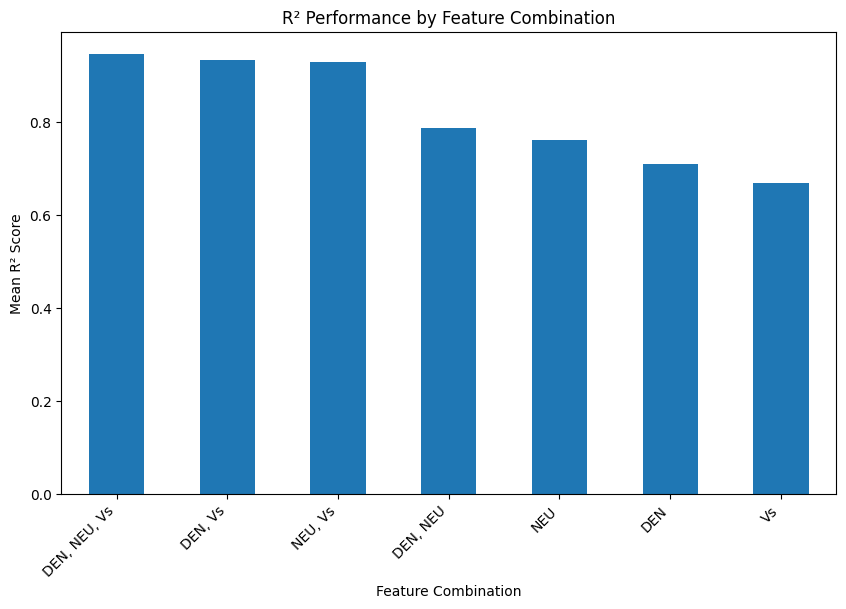

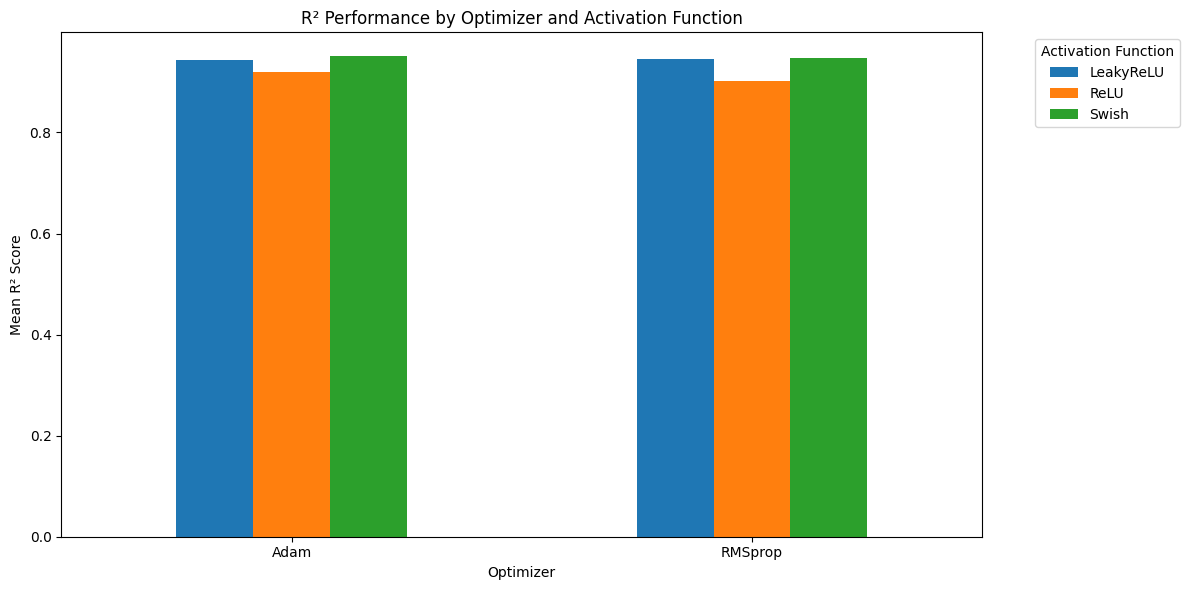

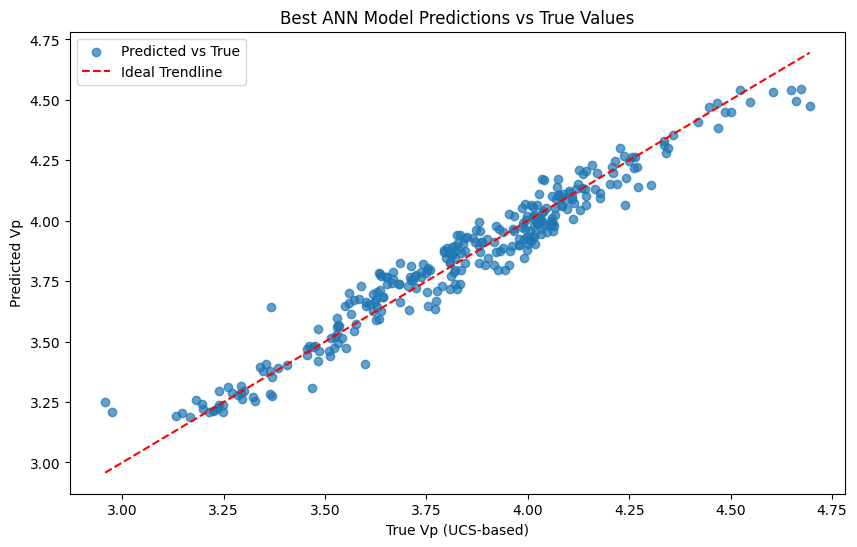

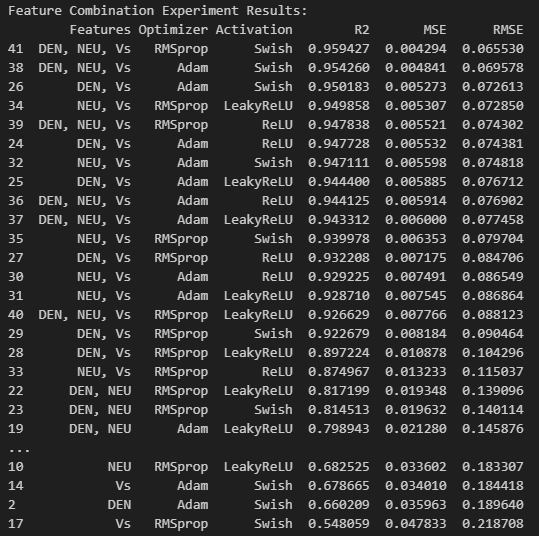

# Discussion
The findings of this study emphasize the critical role of machine learning in enhancing geophysical property predictions, particularly P-wave velocity (Vp). The results not only highlight the strengths of Artificial Neural Networks (ANNs) over traditional empirical models but also provide valuable insights into feature selection, model optimization, and performance evaluation.

1. The Importance of Feature Selection

Feature combination experiments revealed that using all three input features—density (DEN), neutron porosity (NEU), and shear wave velocity (Vs)—consistently provided the best predictive accuracy. This underscores the complementary nature of these features in capturing the physical relationships influencing Vp. Notably, while individual features like Vs and DEN yielded acceptable performance, the inclusion of NEU in combination with the others enhanced the model’s ability to generalize and handle complex relationships. This finding suggests that comprehensive feature engineering is essential for achieving robust geophysical predictions.

2. ANN Superiority over Empirical Models

The ANN models significantly outperformed traditional empirical models such as Gardner’s and Castagna’s equations. Despite parameter optimization, the Gardner model achieved a relatively low R² of 0.6789, while the Castagna model performed even worse, with an R² of 0.4980. These results reflect the inherent limitations of empirical models, which are often constrained by their rigid assumptions and inability to account for nonlinearities and interactions among features. In contrast, the ANN models effectively leveraged the full dataset, achieving an R² of 0.9594 with the optimal configuration (RMSprop and Swish). This highlights the adaptability and scalability of machine learning approaches for complex geophysical datasets.

3. The Role of Optimizers and Activation Functions

The choice of optimizers and activation functions had a significant impact on ANN performance. The Swish activation function, with its smooth gradient and self-gating properties, consistently outperformed traditional activation functions like ReLU and LeakyReLU. Similarly, the RMSprop optimizer outshone Adam, particularly for larger feature combinations, suggesting its ability to efficiently adapt learning rates during training. These results underscore the importance of systematically testing and optimizing model configurations to achieve the best performance.

4. Insights from Visualization

Visualization of the results provided additional clarity on model performance:

Bar charts comparing feature combinations and ANN configurations illustrated the importance of both comprehensive feature sets and proper configuration tuning.
The scatter plot of true vs. predicted Vp values for the best ANN model revealed a strong linear relationship, demonstrating the model’s ability to capture the underlying patterns in the data. The alignment of points along the ideal trendline reinforces the reliability of the ANN predictions.
5. Practical Implications

The results have important implications for geophysical modeling and exploration. The superiority of ANN-based models indicates that incorporating machine learning into workflows can significantly improve the accuracy and reliability of subsurface property predictions. Furthermore, the ability to handle multiple features and complex relationships makes ANNs particularly suited for heterogeneous and nonlinear datasets commonly encountered in geophysics.

6. Limitations and Future Work

While this study highlights the potential of ANNs, it also points to areas for improvement. The reliance on a relatively small dataset limits the generalizability of the findings to broader geophysical applications. Additionally, this study focused exclusively on ANN architectures; exploring other advanced machine learning techniques such as gradient boosting or ensemble learning could provide further insights. Future work could also investigate the integration of domain-specific knowledge into feature engineering and model design to enhance interpretability and performance.

# Conclusion
The results of this study demonstrate that ANN-based models, when properly configured and trained, can significantly outperform traditional empirical models in predicting Vp. By leveraging comprehensive feature sets and modern optimization techniques, machine learning offers a powerful tool for advancing geophysical property predictions, with broad applicability to resource exploration and reservoir characterization.


# Self-Reflection
Overall, this project has been a significant learning experience, equipping me with technical expertise, problem-solving skills, and a deeper appreciation for the power of machine learning in geophysical applications. It has reinforced the importance of combining domain knowledge with computational methods to address complex problems and has left me eager to continue exploring this field. -Sivert Tilset

# Bibliography

